In [4]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

In [1]:
CKPT_PATH = '/home/jovyan/.cache/modelscope/hub/models/facebook/sam3/sam3.pt'

# SAM 3 Agent

This notebook shows an example of how an MLLM can use SAM 3 as a tool, i.e., "SAM 3 Agent", to segment more complex text queries such as "the leftmost child wearing blue vest".

## Env Setup

First install `sam3` in your environment using the [installation instructions](https://github.com/facebookresearch/sam3?tab=readme-ov-file#installation) in the repository.

In [2]:
import torch
# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook. If your card doesn't support it, try float16 instead
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# inference mode for the whole notebook. Disable if you need gradients
torch.inference_mode().__enter__()

In [3]:
import os

SAM3_ROOT = os.path.dirname(os.getcwd())
os.chdir(SAM3_ROOT)

# setup GPU to use -  A single GPU is good with the purpose of this demo
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
_ = os.system("nvidia-smi")

Wed Dec 10 08:06:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:19:00.0 Off |                    0 |
| N/A   36C    P0            124W /  700W |   67046MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Build SAM3 Model

In [4]:
import sam3
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path, checkpoint_path=CKPT_PATH)
processor = Sam3Processor(model, confidence_threshold=0.5)

## LLM Setup

Config which MLLM to use, it can either be a model served by vLLM that you launch from your own machine or a model is served via external API. If you want to using a vLLM model, we also provided insturctions below.

In [5]:
LLM_CONFIGS = {
    # vLLM-served models
    "qwen3_vl_8b_thinking": {
        "provider": "vllm",
        "model": "Qwen/Qwen3-VL-8B-Thinking",
    }, 
    "qwen3_vl_30b_thinking": {
        "provider": "vllm",
        "model": "Qwen/Qwen3-VL-30B-A3B-Thinking",
    }, 
    "qwen3_vl_8b_instruct": {
        "provider": "vllm",
        "model": "Qwen/Qwen3-VL-8B-Instruct",
    }
    # models served via external APIs
    # add your own
}

model = "qwen3_vl_8b_thinking"
LLM_API_KEY = "DUMMY_API_KEY"

llm_config = LLM_CONFIGS[model]
llm_config["api_key"] = LLM_API_KEY
llm_config["name"] = model

# setup API endpoint
if llm_config["provider"] == "vllm":
    LLM_SERVER_URL = "http://0.0.0.0:8001/v1"  # replace this with your vLLM server address as needed
else:
    LLM_SERVER_URL = llm_config["base_url"]

### Setup vLLM server 
This step is only required if you are using a model served by vLLM, skip this step if you are calling LLM using an API like Gemini and GPT.

* Install vLLM (in a separate conda env from SAM 3 to avoid dependency conflicts).
  ```bash
    conda create -n vllm python=3.12
    pip install vllm --extra-index-url https://download.pytorch.org/whl/cu128
  ```
* Start vLLM server on the same machine of this notebook
  ```bash
    # qwen 3 VL 8B thinking
    vllm serve Qwen/Qwen3-VL-8B-Thinking --tensor-parallel-size 4 --allowed-local-media-path / --enforce-eager --port 8001
  ```

## Run SAM3 Agent Inference

In [6]:
from functools import partial
from IPython.display import display, Image
from sam3.agent.client_llm import send_generate_request as send_generate_request_orig
from sam3.agent.client_sam3 import call_sam_service as call_sam_service_orig
from sam3.agent.inference import run_single_image_inference

/home/jovyan/users/koodiazhnyi/3DVG/sam3/sam3/agent/agent_core.py:203: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (


In [7]:
import pycocotools.mask as mask_utils

In [8]:
import cv2

In [9]:
# prepare input args and run single image inference
PATH = "/home/jovyan/users/koodiazhnyi/3DVG/scene0046_00_outputs_42"
image = f"{PATH}/frame.jpg"
with open(os.path.join(PATH, 'prompt.txt'), 'r') as f:
    prompt = f.read()
prompt = prompt.strip()
image = os.path.abspath(image)
send_generate_request = partial(send_generate_request_orig, server_url=LLM_SERVER_URL, model=llm_config["model"], api_key=llm_config["api_key"])
call_sam_service = partial(call_sam_service_orig, sam3_processor=processor)
final_output_dict = run_single_image_inference(
    image, prompt, llm_config, send_generate_request, call_sam_service, 
    debug=False, output_dir="agent_output_qwen8b3"
)

orig_h = int(final_output_dict["orig_img_h"])
orig_w = int(final_output_dict["orig_img_w"])
rle_masks = [
            {"size": (orig_h, orig_w), "counts": rle}
            for rle in final_output_dict["pred_masks"]
        ]
binary_masks = [mask_utils.decode(rle) for rle in rle_masks]

print(binary_masks[0])

------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt: this is a black tv. it is above a bed.
> Image path: /home/jovyan/users/koodiazhnyi/3DVG/scene0046_00_outputs_42/frame.jpg



------------------------------ Round 1------------------------------



image_path /home/jovyan/users/koodiazhnyi/3DVG/scene0046_00_outputs_42/frame.jpg
🔍 Calling model Qwen/Qwen3-VL-8B-Thinking...

>>> MLLM Response [start]
I need to analyze this scenario carefully to determine what the user is asking me to ground.

The initial user input query is: 'this is a black tv. it is above a bed.'

First, let's analyze the image:
- There's a room that appears to be a bedroom
- There's a bed with white sheets and a blue blanket
- There's a TV mounted on the wall above what looks like a small bedside cabinet or shelf
- There's a framed picture on the wall above the bed
- There's a door to the left side of the image
- There's a backpack on the floor near the bed

T

In [10]:
import matplotlib.pyplot as plt

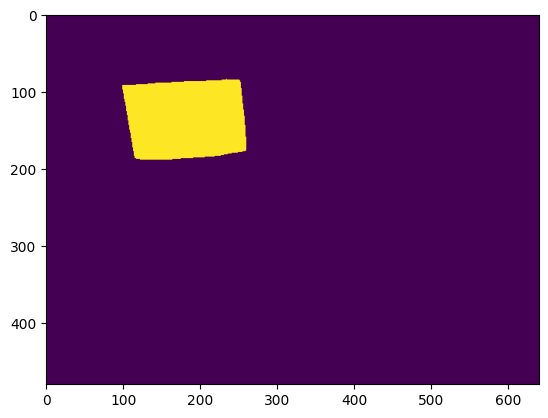

In [13]:
plt.imshow(binary_masks[0])

In [18]:
binary_masks[0].shape

(480, 640)